# SINGLE CELL RNA SEQUENCING ANALYSIS (STAR) - PART I

### Created by: Holly Vose
### Last Modified: 3/25/2026
This notebook is intended for the analysis of STAR/10X Genomics aligned and outputted single cell RNA sequencing data. 

Much of this notebook was also taken from the scanpy basic tutorial on single-cell RNA sequencing processing: https://scanpy.readthedocs.io/en/latest/tutorials/basics/clustering.html

In [1]:
#STEP 1: IMPORTS
#Load this first

import warnings
import scanpy as sc
import scanpy as sc
import anndata as ad
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import doubletdetection

warnings.filterwarnings('ignore')

/projects/hvose@xsede.org/software/anaconda/envs/jupyter_scrna/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## PRE-PREPROCESSING
In order to properly analyze the data, it needs to be loaded and processed accordingly.

### AnnData Objects
AnnData objects are specialized data structures built to handle high-density information and data, in the form of **Ann**otated **Data** Matrices.
These data matrices can hold a lot of information about the cells.

In an AnnData object, there are three major axes: **observations**, **variables**, and **unstructured**.

- **Observations** are the literal cell barcodes. These are the rows of the matrix, where each row represents a specific cell barcode. Can also include counts and other observations related to cell groupings and metrics.
- **Variables** are the genes and other metrics that describe the cell. This includes (but is not limited to) gene expression levels, QC metrics, and annotations such as cell type.
- **Unstructured** is not necessarily associated with either observations or variables, but contain important information about the data (this can include graph colors, dotplots, and other nonspecific analyses)

Steps 2 and 3 will ensure that:

a. Our data is loaded properly \
b. The observations (barcodes) and variables (genes) are unique (if there are repeats, flags are added to the end of the barcode to make them unique) \
c. All of our samples are loaded into a single AnnData object.

Additionally, you can add extra columns here to add information that is not contained in the original data (such as infection type, sample type, etc...)

In [2]:
#STEP 2: LOAD THE SAMPLES
#Loads all outputted alignment files into a dictionary with corresponding sample names.
filtered_samples = {"sample_1":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/fixed_scRNA_run1/outs/per_sample_outs/sample1/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_2":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/fixed_scRNA_run1/outs/per_sample_outs/sample2/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_3":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/fixed_scRNA_run1/outs/per_sample_outs/sample3/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_4":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/fixed_scRNA_run1/outs/per_sample_outs/sample4/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_5":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/fixed_scRNA_run1/outs/per_sample_outs/sample5/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_6":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/fixed_scRNA_run1/outs/per_sample_outs/sample6/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_7":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/fixed_scRNA_run1/outs/per_sample_outs/sample7/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_8":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/fixed_scRNA_run1/outs/per_sample_outs/sample8/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_9":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/fixed_scRNA_run1/outs/per_sample_outs/sample9/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_10":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/fixed_scRNA_run1/outs/per_sample_outs/sample10/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_11":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/fixed_scRNA_run1/outs/per_sample_outs/sample11/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_12":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/fixed_scRNA_run1/outs/per_sample_outs/sample12/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_13":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/fixed_scRNA_run1/outs/per_sample_outs/sample13/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_14":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/fixed_scRNA_run1/outs/per_sample_outs/sample14/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_15":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/fixed_scRNA_run1/outs/per_sample_outs/sample15/count/sample_filtered_feature_bc_matrix.h5",
                   "sample_16":"/scratch/alpine/hvose@xsede.org/fixed_scRNA/fixed_scRNA_run1/outs/per_sample_outs/sample16/count/sample_filtered_feature_bc_matrix.h5"}

In [5]:
#STEP 2: LOAD THE SAMPLES
#this is for non-H5 files
filtered_samples = {"MHVY_Colon_5dpi_1": "/scratch/alpine/hvose@xsede.org/Krishnamurthy_07152025_GEX/STAR_scRNA/MHVY_Colon_5dpi_1/Solo.out/Gene/filtered/",
                   "MHVY_Colon_5dpi_2": "/scratch/alpine/hvose@xsede.org/Krishnamurthy_07152025_GEX/STAR_scRNA/MHVY_Colon_5dpi_2/Solo.out/Gene/filtered/",
                   "MHVY_Colon_5dpi_3": "/scratch/alpine/hvose@xsede.org/Krishnamurthy_07152025_GEX/STAR_scRNA/MHVY_Colon_5dpi_3/Solo.out/Gene/filtered/",
                   "Uninfected_1": "/scratch/alpine/hvose@xsede.org/Krishnamurthy_07152025_GEX/STAR_scRNA/Uninfected_1/Solo.out/Gene/filtered/",
                   "Uninfected_2": "/scratch/alpine/hvose@xsede.org/Krishnamurthy_07152025_GEX/STAR_scRNA/Uninfected_2/Solo.out/Gene/filtered/",
                   "Uninfected_3": "/scratch/alpine/hvose@xsede.org/Krishnamurthy_07152025_GEX/STAR_scRNA/Uninfected_3/Solo.out/Gene/filtered/"}

In [13]:
#STEP 3: GENERATE ANNDATA OBJECT WITH SAMPLES
#For each item in our dictionary, we want to read in the info, make the cells unique, and then combine them into a single object
#Additionally, we are going to add an "infection type" (i_type) column that specifies the infection type based on the loaded sample.

adatas = {}

for sample_id, filename in filtered_samples.items():
    sample_adata = sc.read_10x_mtx(filename,compressed=False)
    #sample_adata = sc.read_10x_h5(filename)
    sample_adata.var_names_make_unique()
    adatas[sample_id] = sample_adata

adata = ad.concat(adatas, label="sample")
adata.obs['i_type'] = 'Mock'
adata.obs_names_make_unique()

adata.obs.loc[adata.obs["sample"] == "MHVY_Colon_5dpi_1", 'i_type'] = '5DPI'
adata.obs.loc[adata.obs["sample"] == "MHVY_Colon_5dpi_2", 'i_type'] = '5DPI'
adata.obs.loc[adata.obs["sample"] == "MHVY_Colon_5dpi_3", 'i_type'] = '5DPI'

#Display our AnnData object via observations
adata.shape


(117718, 40414)

## PREPROCESSING
If `adata.obs` was printed, we should see three columns: one with the cell barcodes, one with the **sample** name, and one with the **i_type**.
We can now move on to regular preprocessing.

### QUALITY CONTROL

Depending on the goal of the analysis, it may be helpful to generate quality control metrics on the dataset. The built-in `sc.pp.calculate_qc_metrics` function will automatically generate helpful metrics, including:

- Number of genes by count
- Total number of gene counts
- Percentage of specific gene counts

By providing what to analyze, we can get a broad, initial look at what gene expression levels look like. You can either specify a single gene, or a family of genes based on their naming conventions (i.e. all mitochondrial genes have the same naming scheme: MT- for human, mt- for mouse). If making new columns for multiple genes, you can call the QC function on everything at once by putting multiple column names in the `qc_vars` parameter.

In [14]:
#STEP 4: Generate QC metrics for our "MHV-Y" gene and our mitochondrial counts
#NOTE: Because MHV-Y was part of our custom transcriptome during alignment, this can't be used for fixed scRNA.
adata.var["mt"] = adata.var_names.str.startswith("mt-")
#adata.var["mhvy"] = adata.var_names.str.contains("Mhvy")

sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt"], inplace=True, log1p=True
)

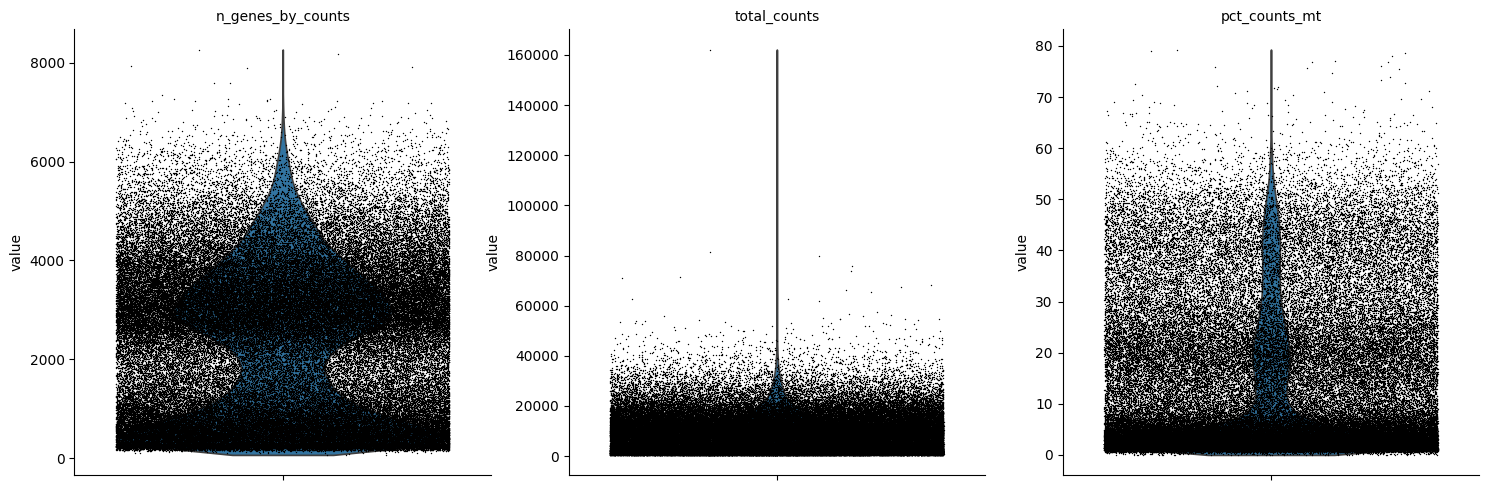

(-5.0, 10000.0)

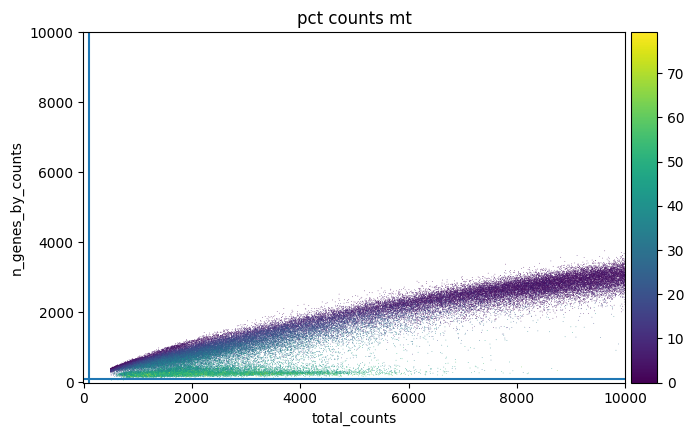

In [15]:
%matplotlib inline
#STEP 4.5: Visualizing the generated QC metrics. Note that if other columns are specified, their specific
#counts will be labeled as pct_counts_[column name]

sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts","pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)
ax = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts",color="pct_counts_mt",show=False)
ax.axhline(y=100)
ax.axvline(x=100)
ax.set_xlim(-5,10000)
ax.set_ylim(-5,10000)

### GETTING A FILTERED OBJECT
When attempting to filter for cells with specific gene expression, it can be useful to return an AnnData object of all the cells associated with a positive gene expression.
To do this, we can assign a new variable of all the cell barcode names where our gene counts are greater than 0. Conversely, if we want to filter out cells with too many gene counts 
(i.e. cells with very high mitochondrial gene counts are often associated with cell stress), we can look at our violin plot to determine an optimal level of filtering.

The main takeaway here is that quality control is an active process, and downstream analysis may require revisiting prior thresholds to properly fine tune the data. 

In [16]:
#STEP 5: Filtering for just MHV-Y positive barcodes (or getting rid of cells with too high of a mitochondrial count)
adata_mid_filter = adata[adata.obs['pct_counts_mt']<5]

#adata_mid_filter = adata[adata.obs['pct_counts_mhvy']>0]

#If just cell barcodes are desired, you can add .obs_names to the end of the above statement.

#For context in the next section, we will print the dimensions of our current object.
adata_mid_filter.shape

(61243, 40414)

In [17]:
del adata

(-5.0, 10000.0)

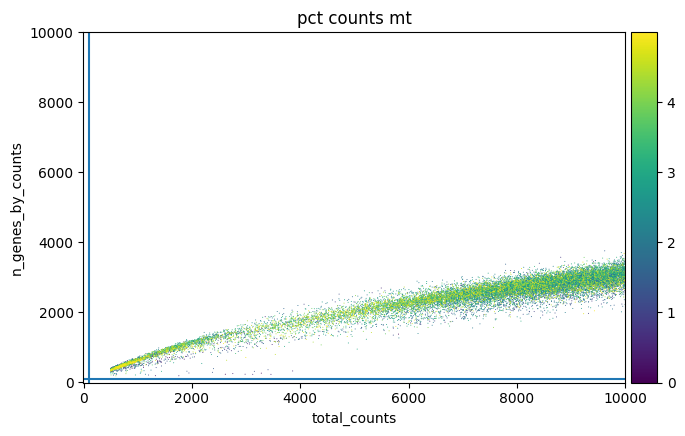

In [18]:
#STEP 4.5: Visualizing the generated QC metrics. Note that if other columns are specified, their specific
#counts will be labeled as pct_counts_[column name]

# sc.pl.violin(
#     adata,
#     ["n_genes_by_counts", "total_counts","pct_counts_mt"],
#     jitter=0.4,
#     multi_panel=True,
# )
ax = sc.pl.scatter(adata_mid_filter, "total_counts", "n_genes_by_counts",color="pct_counts_mt",show=False)
ax.axhline(y=100)
ax.axvline(x=100)
ax.set_xlim(-5,10000)
ax.set_ylim(-5,10000)

### KEEPING 'VALID' CELLS
The next three steps relate to how we determine which cells are biologically relevant for analysis. Using `adata_mid_filter.shape` we can see how many cells/genes are filtered out as a result of our next steps.

#### CELL FILTERING
First, we only want to keep cells that express at least one gene. By using `sc.pp.filter_cells` with the parameter `min_genes=1`, we automatically throw away any cell barcodes associated with no gene expression.

**How does a cell end up with no gene expression?** Typically as a combination of "biological" zeros and "technical" zeros. Biological zeros represent a lack of gene expression because these genes are not expressed in this cell type. Technical zeros are an issue related to sequencing where the sequencer does not detect the minimal amount of mRNA needed for capture, or due to sampling error of the cells.

#### GENE FILTERING
Next, we consider that every possible gene contained in our reference genome are not all expressed within our dataset. As such, we can keep genes that are expressed in at least one cell using `sc.pp.filter_genes` with the setting `min_cells=1`. 

#### DOUBLET DETECTION
In scRNA-seq, **doublets** are cells that contain the information and expression levels from two cells, but are displayed as a single cell. These come from sampling and sequencing errors, but can be computationally detected through a variety of methods. Scanpy has a built-in function called `scrublet` that detects potential doublets and saves their information for later use. 

***NOTE:*** This can take a while, as it profiles every cell in the population and computationally evaluates every single expression profile to determine doublet potential. 



In [19]:
#STEP 6: Filter out cells with less than 1 gene expressed, and display the dimensions of our AnnData object
sc.pp.filter_cells(adata_mid_filter, min_genes=30)
adata_mid_filter.shape

(61243, 40414)

In [20]:
#STEP 7: Filter out genes that are expressed in no cells
sc.pp.filter_genes(adata_mid_filter, min_cells=5)
adata_mid_filter.shape

(61243, 21239)

In [21]:
#STEP 8: Search for cells that are likely doublets. This can take a while!
#The batch_key is an optional parameter to differentiate between sampling batches, should not affect final result.
sc.pp.scrublet(adata_mid_filter, batch_key="sample")

In [ ]:
#this crashes the kernel >:(
clf = doubletdetection.BoostClassifier(
    n_iters=10, 
    clustering_algorithm="leiden", 
    standard_scaling=True,
    pseudocount=0.1,
    n_jobs=1,
)
doublets = clf.fit(adata.X).predict(p_thresh=1e-16, voter_thresh=0.5)
doublet_score = clf.doublet_score()

  0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
#this is for the cell above (which crashes the kernel)
adata.obs["doublet"] = doublets
adata.obs["doublet_score"] = doublet_score

## NORMALIZATION
Now that we have trimmed down our dataset, we want to normalize our data using a count depth scaling and log + 1 normalization scheme. Because scanpy will adjust the values directly, it is helpful to save an extra layer of our count data in case it needs to be referenced later.

In [22]:
#STEP 9: Save the count data as its own layer
adata_mid_filter.layers["counts"] = adata_mid_filter.X.copy()

In [23]:
#STEP 10: Normalize and log-scale the data
sc.pp.normalize_total(adata_mid_filter)
sc.pp.log1p(adata_mid_filter)

## FEATURE SELECTION
Even after our normalization and cell filtering, we still have over 20,000 genes contained in our dataset. For the purpose of our analysis, we want to try and reduce the dimensionality of our dataset to only look at the most descriptive and informative genes in our dataset. We can do this by using the built in `sc.pp.highly_variable_genes` function to determine which genes are the most representative of our dataset, based on the `batch_key` parameter. In this example, we want to find the 2000 most highly variable genes per infection type. 

Similar to the doublet detection, this will take a while as the whole dataset must be analyzed several times. 

If desired, this step can mimic the detection features of Seurat, CellRanger, or Seurat v3 using the `flavor` parameter. Seurat is the default.

In [24]:
#STEP 11: Calculate the most highly variable genes in our dataset. This can take a while!
sc.pp.highly_variable_genes(adata_mid_filter, n_top_genes=2000)

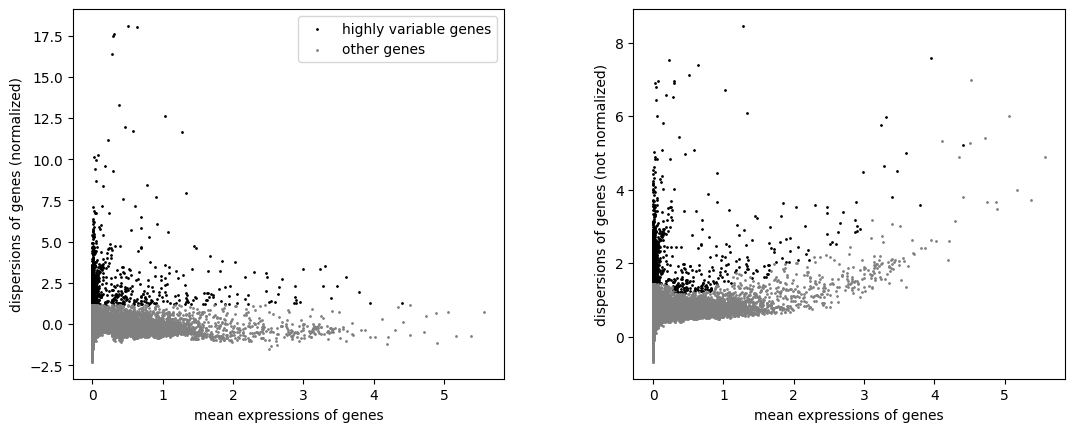

In [25]:
#STEP 11.5: Plot our highly variable genes
sc.pl.highly_variable_genes(adata_mid_filter)

## CLUSTERING
With our genes properly filtered and taken care of, we can now move on to the bulk of the analysis.

### CLUSTER REPRESENTATION
We can visualize our data by clustering our cells based on their relative log-transformed gene counts. By determining which cells are closely related on a few key dimensions, we can create a 2-dimensional representation of our data. There are two ways to do this:
1. Uniform Manifold Approximation and Projection (UMAP)
2. t-Stochastic Neighbor Embedding (t-SNE)
For an in-depth explanation, read more here: https://alleninstitute.org/resource/what-is-a-umap/

<span style="color:red">**WARNING!** UMAPs and t-SNEs are tools, not results!</span>

Something important to recognize is that the UMAP is a mathematical representation of our data; it is highly sensitive and can be prone to over-describing data. Also, because UMAPs are based on clustering algorithms, no two **newly** generated representations are quite the same (though you can get very close with specific parameters.)

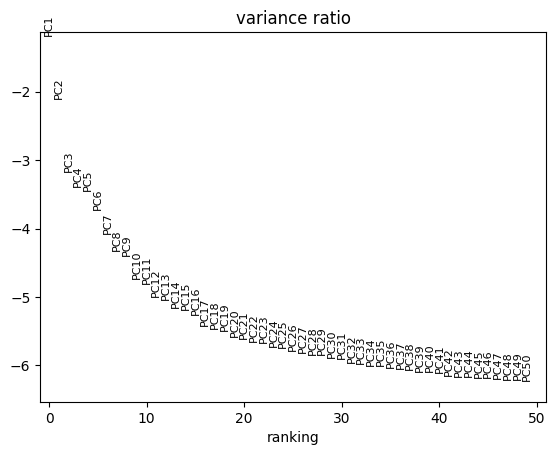

In [26]:
#STEP 12: Calculate PCA for our sample and plot the first 50 principal components. If there is a noticeable flattening in the graph at a particular component, adjust the following step accordingly.
%matplotlib inline
sc.pp.pca(adata_mid_filter)
sc.pl.pca_variance_ratio(adata_mid_filter, n_pcs=50, log=True)

In [27]:
#STEP 13: Calculate cell clusters based on a specified number of principal components. Based on the PCA from the previous step, if there is a noticeable flattening 
sc.pp.neighbors(adata_mid_filter, n_pcs=16)
sc.tl.umap(adata_mid_filter)
#sc.tl.tsne(adata_mid_filter)

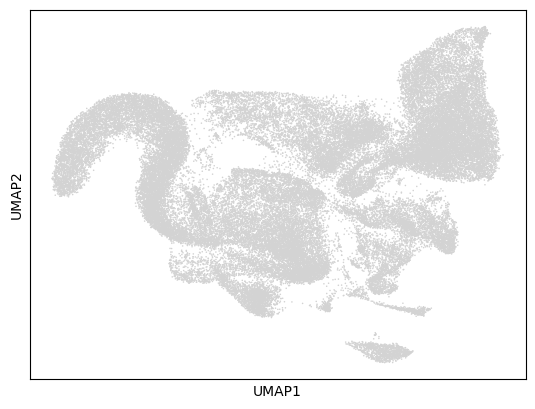

In [28]:
#STEP 14 (option 1): Plot the UMAP visualization
sc.pl.umap(
    adata_mid_filter,
    # Setting a smaller point size to prevent overlap
    size=5
)

In [29]:
#STEP 14 (option 2): Plot the t-SNE visualization
sc.pl.tsne(
    adata_mid_filter,
    color=['i_type'],
    # Setting a smaller point size to prevent overlap
    size=5
)

KeyError: "Could not find 'tsne' or 'X_tsne' in .obsm"

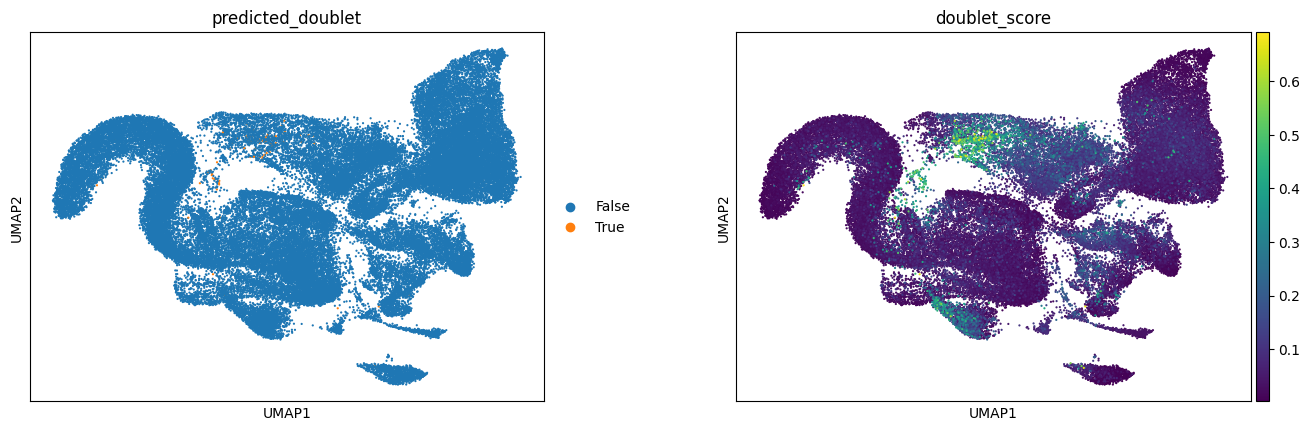

In [30]:
#STEP 15: Show predicted doublets and which cells have higher doublet scoring (more likely to be doublets)
sc.pl.umap(
    adata_mid_filter,
    color=["predicted_doublet", "doublet_score"],
    # increase horizontal space between panels
    wspace=0.25,
    size=10,
)

In [31]:
#STEP 16: Create a copy of the dataset without cells where predicted_doublet is True
adata_filtered = adata_mid_filter[~adata_mid_filter.obs['predicted_doublet'] > 0.3].copy()

In [34]:
del adata_mid_filter

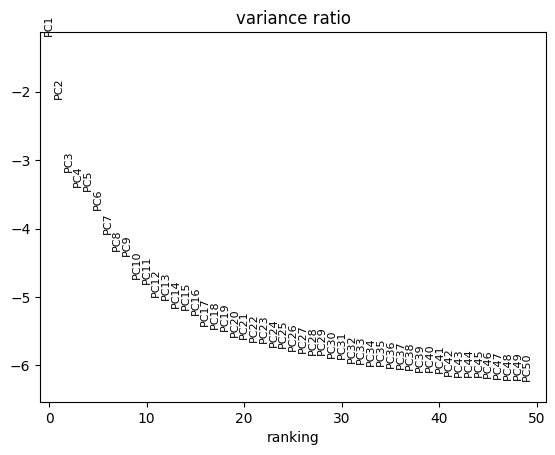

In [32]:
#STEP 17: Rerun our PCA to generate new principal components for the clustering
sc.pp.pca(adata_filtered)
sc.pl.pca_variance_ratio(adata_filtered, n_pcs=50, log=True)

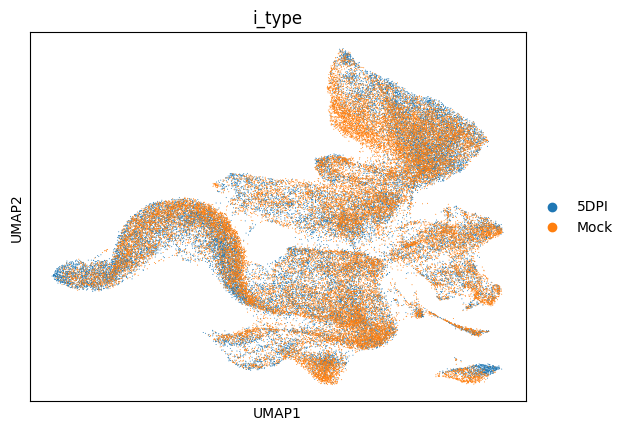

In [33]:
#STEP 18: Rerun all of our clustering on the new, filtered dataset
sc.pp.neighbors(adata_filtered,n_pcs=16)
sc.tl.umap(adata_filtered)
sc.tl.leiden(adata_filtered, flavor="igraph", n_iterations=2)
sc.pl.umap(adata_filtered, color="i_type")

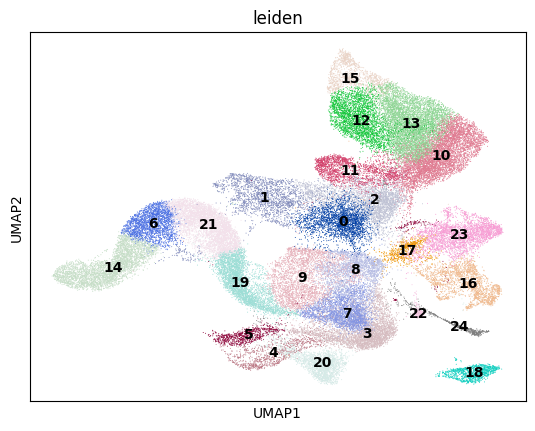

(61124, 21239)

In [42]:
sc.pl.umap(adata_filtered,color="leiden",legend_loc="on data")
adata_filtered.shape

In [35]:
#STEP 19: Export the AnnData Object
adata_filtered.write_h5ad("adata_live_refiltered_20260507.h5ad")

In [36]:
#COLOR DEFINITIONS
infected_colors = {
    "infected": "#582B36",
    "uninfected": "#582B36"
}

i_contrast_colors = ["#E2552D","#2E5283"]
ifitm_hex = ["#BEBDBD", "#DF3848"]
aggressive_hex = ["#FFFFFF","#000000"]

ifitm_cmap = mcolors.LinearSegmentedColormap.from_list("ifitm_cmap",ifitm_hex)
aggr_cmap = mcolors.LinearSegmentedColormap.from_list("aggr_cmap",aggressive_hex)

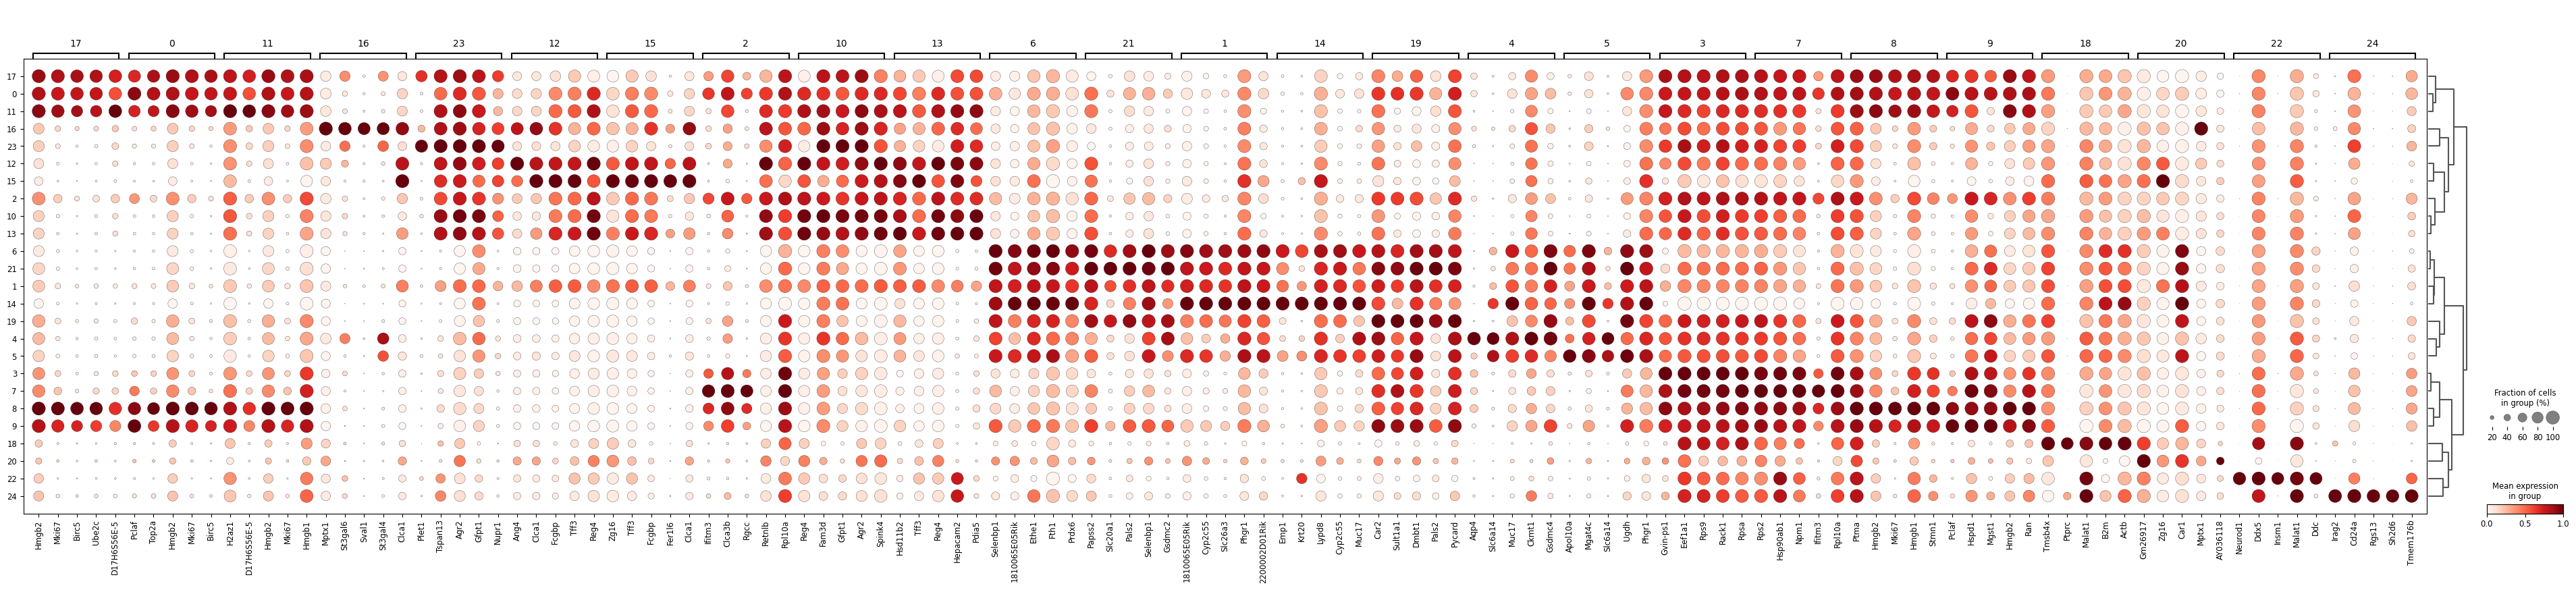

In [37]:
#generate most differentially expressed genes per cluster
sc.tl.rank_genes_groups(adata_filtered, groupby="leiden", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(
    adata_filtered, groupby="leiden", standard_scale="var", n_genes=5
)

In [99]:
#CLUSTER DEFINITIONS
#Stem Cell: Lgr5+, Ascl2+, Muc2-, Lrig1+ (ideally)
#Tuft Cell: Dclk1+
#Colonocytes: Slc26a3+, Krt20+, Aqp8+
#TA Cells: Foxm1, Ube2c+
#Goblet Cell Progenitor: Spdef+, Atoh1+
#Goblet Cell: Reg4+, Spink4+, Tff3+, Fad3+
#Immune Signaling Cells: B2m+, Cd3g+
#EC Progenitors: B3galt5+
#Actin-Associated Genes: Actb+, Car1, Krt8

cluster2annotation = {
    "0": "Stem Cell", #Lgr5+, Muc2-, Ascl2+
    "1": "High Mitochondrial Gene Count",
    "2": "Actin-Associated Genes", 
    "3": "High Ribosomal Gene Count", 
    "4": "Goblet Cell", 
    "5": "High Mitochondrial Gene Count",
    "6": "Goblet Cell",
    "7": "Transit Amplifying (TA) Cell", #Foxm1+, Ube2c+
    "8": "Stem Cell", #stem cell? Lrig1+
    "9": "Enterocytes", #enterocytes
    "10": "Ribosomal/MHC Signatures", #Dclk+
    "11": "Transit Amplifying (TA) Cell", #Ube2c+, Foxm1+
    "12": "Goblet Cell Progenitor", #Spdef+, #Atoh1+
    "13": "Enterocyte???", #Phgr1+
    "14": "Goblet Cell",
    "15": "Goblet Cell Progenitor", 
    "16": "Goblet Cell", 
    "17": "Transit Amplifying (TA) Cell", #Ube2c+, Foxm1+
    "18": "Absorptive Colonocytes",
    "19": "Absorptive Colonocytes",
    "20": "",
    "21": "Immune Signaling Cells", #MHC Class I (B2m), Cd3g+, Ptprc+
    "22": "Absorptive Colonocytes",
    "23": ""
}

In [46]:
print(list(adata_filtered.var_names))

['Xkr4', 'Gm53491', 'Rp1', 'Gm37323', 'Gm46082', 'Mrpl15', 'Lypla1', 'Gm57794', 'Tcea1', 'Rgs20', 'Gm16041', 'Atp6v1h', 'Npbwr1', 'Gm46206', '4732440D04Rik', 'Rb1cc1', 'Alkal1', 'St18', 'Pcmtd1', 'Gm26901', 'Rrs1', 'Adhfe1', '2610203C22Rik', 'Vxn', 'Mybl1', 'Vcpip1', '1700034P13Rik', 'Gm39590', 'Sgk3', 'Gm6195', 'Mcmdc2', 'Snhg6', 'Tcf24', 'Ppp1r42', 'Cops5', 'Cspp1', 'Arfgef1', 'Cpa6', 'Prex2', 'Gm17644', 'Sulf1', 'Slco5a1', 'Prdm14', 'Ncoa2', 'Tram1', 'Lactb2', 'Xkr9', 'Gm5523', 'Gm39596', 'Eya1', 'Msc', 'Gm9947', 'Kcnb2', 'Gm51616', 'Terf1', 'Sbspon', 'Gm31523', '4930444P10Rik', 'Rpl7', 'Rdh10', 'Stau2', 'Gm7568', 'C130013N14Rik', 'Ube2w', 'Eloc', 'D030040B21Rik', 'Tmem70', 'Ly96', 'Jph1', 'Gdap1', 'Tfap2d', 'Tfap2b', 'Pkhd1', 'Il17a', 'Il17f', 'Mcm3', '6720483E21Rik', 'Paqr8', 'Efhc1', 'Tram2', 'Tmem14a', 'Gsta3', 'Gm7094', 'Gm4956', 'Khdc1a', 'Khdc1b', 'Kcnq5', 'Rims1', 'Gm53541', 'Ogfrl1', 'B3gat2', 'Smap1', 'Gm53062', 'Sdhaf4', 'Fam135a', 'Col9a1', 'Col19a1', 'Lmbrd1', 'Adgrb3',

In [44]:
#cell count per category
print(adata_filtered.obs["leiden"].value_counts())

leiden
13    5428
10    5351
21    4311
14    3967
19    3559
3     3435
12    2997
2     2970
23    2930
7     2790
9     2756
0     2601
6     2222
20    2147
8     2126
16    1973
11    1962
1     1956
15    1225
18    1033
5      948
4      942
17     664
24     626
22     205
Name: count, dtype: int64


In [ ]:
for res in [0.5, 1.2, 1.5]:
    sc.tl.leiden(
        adata_filtered, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph"
    )

In [ ]:
sc.pl.umap(
    adata_filtered,
    color=["leiden_res_0.50", "leiden_res_1.50", "leiden_res_1.00"]
)

In [87]:
#determine which clusters have MHV positive cells in them

clusters = {}
for item in mhvy_filtered:
    try:
        mhv_cluster = adata_filtered[item].obs["leiden"].iloc[0]
    except KeyError as e:
        print(str(e) + " not in valid barcodes")
    if mhv_cluster not in clusters.keys():
        clusters[mhv_cluster] = 1
    else:
        clusters[mhv_cluster] += 1

sorted_items = sorted(clusters.items(), key=lambda item: item[0])
fnl_out = dict(sorted_items)
for keys, values in fnl_out.items():
    print(str(keys) + " " + str(values))

0 1
1 2
10 5
11 1
12 5
13 3
14 3
16 2
17 1
18 3
19 2
20 1
3 4
6 1
7 6


In [ ]:
marker_genes = {
    "Absorptive Enterocytes": ["Maf"],
    "Goblet Cell Progenitors": [],
    "Goblet Cells": ["Muc2","Tff3","Clca1"],
    "Tuft Cells": ["Dclk1"]
}

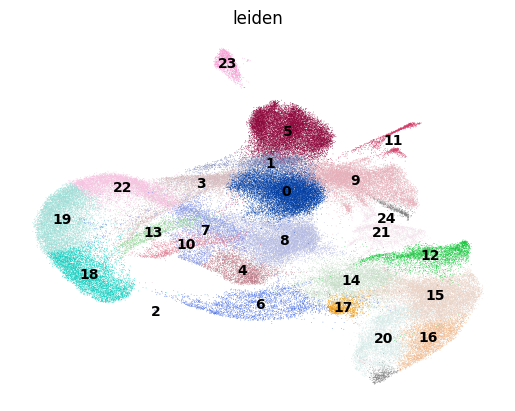

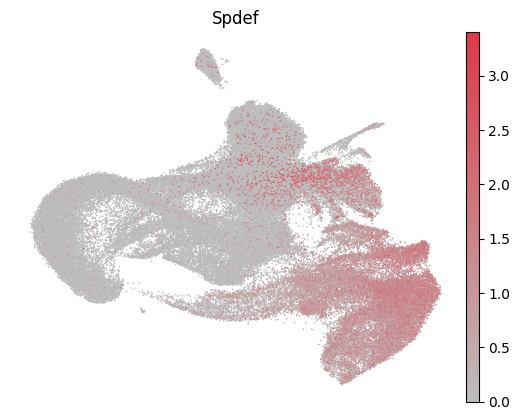

In [25]:
#PLOT HELL

#basic format for a few things:

#BASIC PLOTS
#sc.pl.umap(adata_filtered, color=["cluster_cell_type"],frameon=False,save="clustercelltype.svg")
# sc.pl.umap(adata_filtered, color="i_type",groups=["uninfected"],frameon=False,palette=infected_colors,save="uninfected.svg")
# sc.pl.umap(adata_filtered, color="i_type",groups=["infected"],frameon=False,palette=infected_colors,save="infected.svg")
sc.pl.umap(adata_filtered, color=["leiden"], frameon=False,legend_loc="on data")

sc.pl.umap(adata_filtered, color="Spdef",size=5,frameon=False,cmap=ifitm_cmap)
#sc.pl.umap(adata_filtered, color="Atoh1",size=5,frameon=False,cmap=ifitm_cmap)

#PLOTTING GRADIENTS BASED ON SUB-CATEGORIES
# sc.pl.umap(adata_filtered, color="Muc2",mask_obs=(adata_filtered.obs.i_type=="uninfected"),frameon=False,cmap=ifitm_cmap,title="Muc2 Uninfected",save="muc2uninfected.svg")
# sc.pl.umap(adata_filtered, color="Muc2",mask_obs=(adata_filtered.obs.i_type=="infected"),frameon=False,cmap=ifitm_cmap,title="Muc2 Infected",save="muc2infected.svg")
# sc.pl.umap(adata_filtered, color="Ang4",mask_obs=(adata_filtered.obs.i_type=="uninfected"),frameon=False,cmap=ifitm_cmap,title="Ang4 Uninfected",save="ang4uninfected.svg")
# sc.pl.umap(adata_filtered, color="Ang4",mask_obs=(adata_filtered.obs.i_type=="infected"),frameon=False,cmap=ifitm_cmap,title="Ang4 Infected",save="ang4infected.svg")

#SPECIFIC GENE TEST
#sc.pl.umap(adata_filtered, color="Ptms")
#sc.pl.umap(adata_filtered, color="Aqp8")

#CLUSTER 4
# sc.pl.umap(adata_filtered, color="Clca1",frameon=False,cmap=ifitm_cmap,save="Clca1.svg")
# sc.pl.umap(adata_filtered, color="Ceacam1",frameon=False,cmap=ifitm_cmap)
# sc.pl.umap(adata_filtered, color="Ang4",frameon=False,cmap=ifitm_cmap,save="Ang4.svg")
# sc.pl.umap(adata_filtered, color="Zg16",frameon=False,cmap=ifitm_cmap,save="Zg16.svg")
# sc.pl.umap(adata_filtered, color="Fcgbp",frameon=False,cmap=ifitm_cmap,save="Fcgbp.svg")

#THE LIST
# # sc.pl.umap(adata_filtered, color="Muc2",cmap=ifitm_cmap,save="muc2.svg")
# # #sc.pl.umap(adata_filtered, color="Krt20")
# sc.pl.umap(adata_filtered, color="Lgr5",cmap=ifitm_cmap,frameon=False,save="lgr5.svg")
#sc.pl.umap(adata_filtered, color="Mhvy",size=20,frameon=False,cmap=ifitm_cmap,save="mhvy.svg")
# sc.pl.umap(adata_filtered, color="Clca1",mask_obs=(adata_filtered.obs.i_type=="infected"),cmap=ifitm_cmap)
# sc.pl.umap(adata_filtered, color="Clca1",mask_obs=(adata_filtered.obs.i_type=="uninfected"),cmap=ifitm_cmap)
# sc.pl.umap(adata_filtered, color="Spink4",frameon=False,cmap=ifitm_cmap,save="spink4.svg")
# sc.pl.umap(adata_filtered, color="Clca1",frameon=False,cmap=ifitm_cmap)
# sc.pl.umap(adata_filtered, color="Mptx1",cmap=ifitm_cmap,frameon=False,mask_obs=(adata_filtered.obs.i_type=="infected"))
# sc.pl.umap(adata_filtered, color="Mptx1",cmap=ifitm_cmap,frameon=False,mask_obs=(adata_filtered.obs.i_type=="uninfected"))
# # sc.pl.umap(adata_filtered, color="Spdef",frameon=False,cmap=ifitm_cmap,save="spdef.svg")
# # #sc.pl.umap(adata, color="IGJ", mask_obs=(adata.obs.bulk_labels == "CD19+ B"), size=20)
# #sc.pl.umap(adata_filtered, color="Ifit", mask_obs=(adata_filtered.obs.i_type == "infected"),cmap=ifitm_cmap,na_color="white",frameon=False)
# sc.pl.umap(adata_filtered, color="Epcam",cmap=ifitm_cmap,na_color="white",frameon=False)
# #sc.pl.umap(adata_filtered, color="Cd45",cmap=ifitm_cmap,na_color="white",frameon=False)
# sc.pl.umap(adata_filtered, color="Ifitm2",cmap=ifitm_cmap,na_color="white",frameon=False)
# sc.pl.umap(adata_filtered, color="Ifitm3",cmap=ifitm_cmap,na_color="white",frameon=False)
# sc.pl.umap(adata_filtered, color="Ifitm1",cmap=ifitm_cmap,na_color="white",frameon=False)
# # sc.pl.umap(adata_filtered, color="Ifitm2", mask_obs=(adata_filtered.obs.i_type == "uninfected"),cmap=ifitm_cmap,na_color="white",frameon=False)
# # sc.pl.umap(adata_filtered, color="Ifitm3", mask_obs=(adata_filtered.obs.i_type == "uninfected"),cmap=ifitm_cmap,na_color="white",frameon=False)
# # sc.pl.umap(adata_filtered, color="Ifitm2")
# # sc.pl.umap(adata_filtered, color="Ifitm3")
# sc.pl.umap(adata_filtered, color="Olfm4")
# sc.pl.umap(adata_filtered, color="Best2") #no Best4 or OTOP

# #COLONOCYTES
# sc.pl.umap(adata_filtered, color="Slc12a2",cmap=ifitm_cmap,frameon=False)
# #sc.pl.umap(adata_filtered, color="Krt20")

# # # sc.pl.umap(adata_filtered, color="Ifit2")

# sc.pl.umap(adata_filtered, color="Ifit1")
# # sc.pl.umap(adata_filtered, color="Ifit3")
# sc.pl.umap(adata_filtered, color="Mx2")

# #sc.pl.umap(adata_filtered, color="Muc2")
# sc.pl.umap(adata_filtered, color="Defb29")
# #sc.pl.umap(adata_filtered, color="Epcam")
# sc.pl.umap(adata_filtered, color="Chga")
# # #Muc2, Dclk, Lyz14, Epcam1, Chga

# #TUFT CELLS
#sc.pl.umap(adata_filtered, color="Dclk1",cmap=ifitm_cmap,frameon=False,save="dclk1.svg")

#adata_filtered.obs

#Figure out number of cluster 4 cells in Muc2 expression between 3 and 7


In [ ]:
adata_filtered.var

In [100]:
adata_filtered.obs['cluster_cell_type'] = adata_filtered.obs["leiden"].map(cluster2annotation).astype('category')

categories: Absorptive Colonocytes, Actin-associated Gene Signatures, Colonocytes (Absorptive Enterocytes), etc.
var_group_labels: infected, uninfected


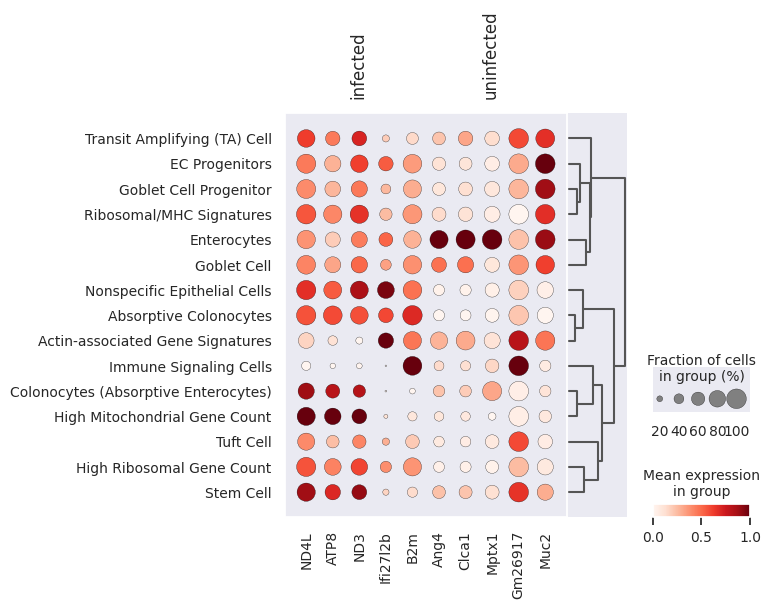

In [98]:
sc.tl.rank_genes_groups(adata_filtered, groupby="i_type", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(
    adata_filtered, groupby="cluster_cell_type", standard_scale="var", n_genes=5, save="i_type_cluster_dotplot.svg"
)

In [94]:
#cluster counts
total_clusters = 22
all_uninfected = []
all_infected = []

for i in range(0, total_clusters):  
    subset_in = adata_filtered[(adata_filtered.obs["leiden"] == str(i)) & (adata_filtered.obs["i_type"] == "infected")].shape[0]
    subset_un = adata_filtered[(adata_filtered.obs["leiden"] == str(i)) & (adata_filtered.obs["i_type"] == "uninfected")].shape[0]
    total = subset_un + subset_in
    print("total: " + str(total))
    #my_clusters[i] = [round(subset_un/total, 2), round(subset_in/total, 2)]
    all_uninfected.append(round(subset_un/total, 2))
    all_infected.append(round(subset_in/total, 2))

print(len(all_uninfected))
print(len(all_infected))

data = {
    "Cluster": list(range(0,22)),
    "Uninfected": all_uninfected,
    "Infected": all_infected
}

df = pd.DataFrame(data)

# for keys, values in my_clusters.items():
#     print(str(keys) + ": " + str(values))

total: 13198
total: 5418
total: 1182
total: 8283
total: 3973
total: 6121
total: 10941
total: 9588
total: 3604
total: 2296
total: 5351
total: 3473
total: 8614
total: 8276
total: 3484
total: 39
total: 3075
total: 1804
total: 6703
total: 7755
total: 3068
total: 1320
22
22


         Infected  Uninfected
Cluster                      
0            0.31        0.69
1            0.35        0.65
2            0.43        0.57
3            0.39        0.61
4            0.49        0.51
5            0.83        0.17
6            0.51        0.49
7            0.34        0.66
8            0.48        0.52
9            0.38        0.62
10           0.40        0.60
11           0.46        0.54
12           0.46        0.54
13           0.39        0.61
14           0.45        0.55
15           0.03        0.97
16           0.37        0.63
17           0.41        0.59
18           0.50        0.50
19           0.48        0.52
20           0.59        0.41
21           0.50        0.50


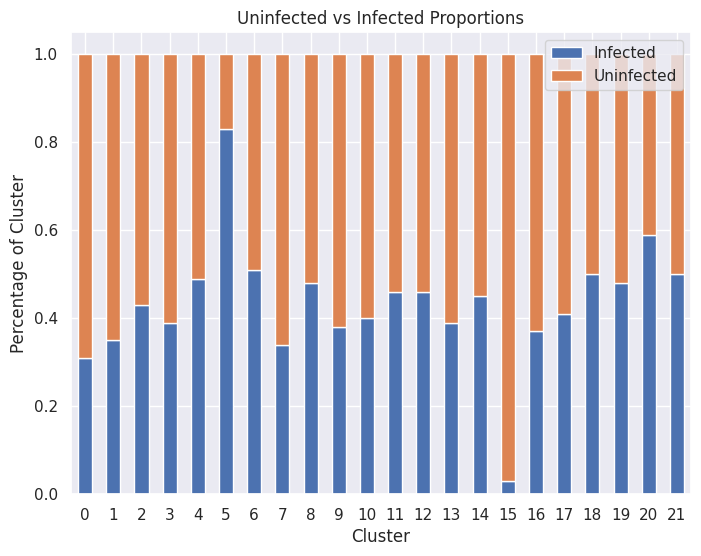

In [97]:
df_pivot = df.pivot_table(index='Cluster', values=['Uninfected','Infected'], aggfunc='sum')

print(df_pivot)

# Set Seaborn style
sns.set_theme()
colors = ["red","blue"]

# Plot using Pandas with stacked=True
df_pivot.plot(kind='bar', stacked=True, figsize=(8, 6))
plt.title('Uninfected vs Infected Proportions')
plt.ylabel('Percentage of Cluster')
plt.xlabel('Cluster')
plt.xticks(rotation=0)
plt.show()

In [ ]:
#Ranking genes by infection then graphing by cluster cell type
sc.tl.rank_genes_groups(adata_filtered, groupby="i_type", method="wilcoxon")

sc.pl.rank_genes_groups_dotplot(
    adata_filtered, groupby="cluster_cell_type", standard_scale="var", n_genes=5, save="i_type_dotplot.svg"
)

In [ ]:
#making this a loop so it isn't stupid

num_clusters = 25

for i in range(0, num_clusters):
    curr_cluster = adata_filtered[(adata_filtered.obs["leiden_res_1.50"] == str(i))].copy()
    sc.tl.rank_genes_groups(curr_cluster, groupby='i_type', reference='uninfected', method='wilcoxon',key_added='i_type_compare')
    current_clus = sc.get.rank_genes_groups_df(curr_cluster, group="infected",key='i_type_compare')
    title = "comp_cluster_1.50_" + str(i) + ".csv"
    current_clus.to_csv(title,index=False)

In [2]:
#second loop for items in cell clusters
adata_filtered

NameError: name 'adata_filtered' is not defined

In [ ]:
sc.pl.rank_genes_groups_dotplot(clus_zero, groupby='i_type', n_genes=10, key='i_type_compare') 
#sc.pl.rank_genes_groups_dotplot(adata_filtered, groupby='leiden', n_genes=10, key='diff_expr_4_2') 

In [ ]:
cluster_four = adata_filtered[(adata_filtered.obs["leiden_"] == "4")].copy()
print(cluster_four.obs)
print(adata_filtered.obs.value_counts)

In [ ]:
#code graveyard

#determine gene presences in MHV positive cells
#TEST: AAAGCCAGTTCCAGAT
all_genes = {}
#test = "AAAGCCAGTTCCAGAT"
all_gene_names = adata_filtered.var_names
# for item in mhvy_filtered.obs_names:
#     mhv_cluster = adata_filtered[item, :]
#     if mhv_cluster not in clusters.keys():
#         clusters[mhv_cluster] = 1
#     else:
#         clusters[mhv_cluster] += 1
for name in all_gene_names:
    all_genes[name] = []

gene_list = []
for barcode in mhvy_filtered.obs_names:
# gene_list = []
# print("checking " + barcode)
    try:
        if adata_filtered[barcode,"Muc2"].X[0,0] > 0:
            gene_list.append(barcode)
    except KeyError as e:
        print(str(e) + " not valid")

len(gene_list)
#len(mhvy_filtered.obs_names)

#find percentage of clusters
my_four_counts = {}
total_cells = 3251
labels = []
values = []
for s_type in list(set(adata_filtered.obs["sample"])):
    my_four_counts[s_type] = 0

for item in cluster_four.obs["sample"]:
    my_four_counts[item] += 1

for key in my_four_counts.keys():
    percent_val = my_four_counts[key] / total_cells
    labels.append(key)
    values.append(percent_val)

print(labels)
print(values)

fig,ax = plt.subplots()

ax.bar(labels, values, label=labels)

ax.set_ylabel('% of cells in cluster 4')
ax.set_title('Cluster 4 Populations')
plt.xticks(rotation=90)
plt.savefig("cluster_4_pops.svg", dpi=300)
